In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import joblib

## Observation

Required libraries were imported successfully.

These libraries will be used for:

- Data Processing
- Feature Engineering
- LTV Calculation
- Regression Modeling
- Model Evaluation
- Model Serialization

In [2]:
df=pd.read_csv("customer_churn_ltv_final.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Avg_Revenue_Per_Month,Customer_Age_Group,Customer_Segment,LTV,LTV_Segment
0,5375,0,0,1,0,1,0,1,0,0,...,1,2,29.85,29.85,0,29.85,1,Low Value,29.85,Bronze
1,3962,1,0,0,0,34,1,0,0,2,...,0,3,56.95,1889.50,0,56.95,0,Medium Value,1936.30,Gold
2,2564,1,0,0,0,2,1,0,0,2,...,1,3,53.85,108.15,1,53.85,1,Medium Value,107.70,Bronze
3,5535,1,0,0,0,45,0,1,0,2,...,0,0,42.30,1840.75,0,42.30,0,Medium Value,1903.50,Gold
4,6511,0,0,0,0,2,1,0,1,0,...,1,2,70.70,151.65,1,70.70,1,High Value,141.40,Bronze


## Observation

The dataset was loaded successfully.

The dataset contains customer demographic information,
service subscriptions, tenure details, monthly charges,
and churn information required for customer lifetime value prediction.

In [3]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors='coerce')
df.dropna(inplace=True)
df.shape

(7043, 26)

## Observation

Missing values in TotalCharges were converted and removed.

The dataset is now clean and ready for LTV calculation.

In [4]:
df["LTV"]=df["MonthlyCharges"]* df["tenure"]
df[["MonthlyCharges","tenure","LTV"]].head()

,MonthlyCharges,tenure,LTV
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


## Observation

Customer Lifetime Value (LTV) was calculated using
Monthly Charges and Customer Tenure.

Customers with longer tenure and higher monthly charges
show significantly higher lifetime value.

In [5]:
df["LTV"].describe()

count    7043.000000
mean     2279.581350
std      2264.729447
min         0.000000
25%       394.000000
50%      1393.600000
75%      3786.100000
max      8550.000000
Name: LTV, dtype: float64

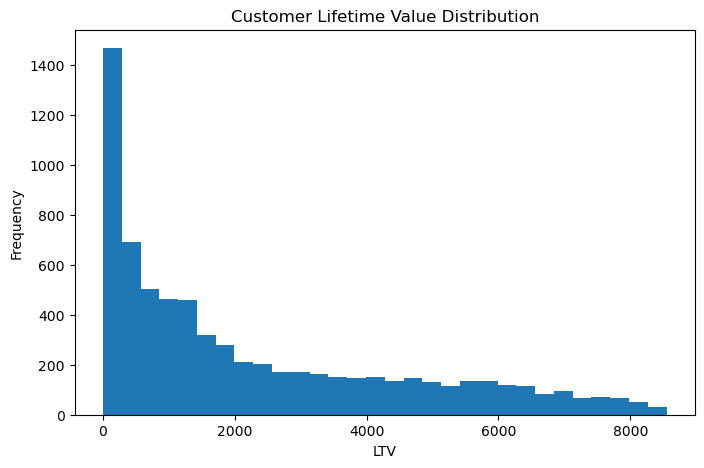

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["LTV"],bins=30)
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("LTV")
plt.ylabel("Frequency")
plt.show()

## Observation

The LTV distribution is positively skewed.

Most customers have moderate lifetime values,
while a smaller group of customers contributes significantly higher revenue.

In [7]:
df_model=df.copy()
df_model.drop(['customerID'],axis=1,inplace=True)
df_model=pd.get_dummies(df_model,drop_first=True)
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,Avg_Revenue_Per_Month,Customer_Age_Group,LTV,Customer_Segment_Low Value,Customer_Segment_Medium Value,LTV_Segment_Gold,LTV_Segment_Platinum,LTV_Segment_Silver
0,0,0,1,0,1,0,1,0,0,2,...,29.85,0,29.85,1,29.85,True,False,False,False,False
1,1,0,0,0,34,1,0,0,2,0,...,1889.50,0,56.95,0,1936.30,False,True,True,False,False
2,1,0,0,0,2,1,0,0,2,2,...,108.15,1,53.85,1,107.70,False,True,False,False,False
3,1,0,0,0,45,0,1,0,2,0,...,1840.75,0,42.30,0,1903.50,False,True,True,False,False
4,0,0,0,0,2,1,0,1,0,0,...,151.65,1,70.70,1,141.40,False,False,False,False,False


## Observation

Categorical variables were converted into numerical
format using One-Hot Encoding.

The dataset is now suitable for machine learning algorithms.

In [8]:
X=df_model.drop("LTV",axis=1)
y=df_model['LTV']
print(X.shape)
print(y.shape)

(7043, 27)
(7043,)


## Observation

Independent variables were separated from the target variable.

Target Variable:
- LTV

Predictor Variables:
- Customer demographics
- Service subscriptions
- Billing information
- Tenure details

In [9]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
    

(5634, 27)
(1409, 27)


## Observation

The dataset was split into training and testing sets.

80% used for training.
20% used for evaluation.

In [10]:
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)
lr_predictions=lr_model.predict(X_test)

In [11]:
mae=mean_absolute_error(y_test,lr_predictions)
rmse=np.sqrt(mean_squared_error(y_test,lr_predictions))
r2=r2_score(y_test,lr_predictions)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 50.692823993546355
RMSE: 78.30912243044743
R2: 0.9988216157118525


## Observation

Linear Regression establishes a baseline model for LTV prediction.

The model captures linear relationships between customer attributes and lifetime value.

In [12]:
rf_model=RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train,y_train)
rf_predictions=rf_model.predict(X_test)

In [13]:
mae_rf=mean_absolute_error(y_test,rf_predictions)
rmse_rf=np.sqrt(mean_squared_error(y_test,rf_predictions))
r2_rf=r2_score(y_test,rf_predictions)

print("MAE:",mae_rf)
print("RMSE:",rmse_rf)
print("R2:",r2_rf)

MAE: 40.12327324343515
RMSE: 62.68202437770796
R2: 0.9992449977305438


## Observation

Random Forest captures non-linear customer behavior patterns.

The model generally provides better prediction accuracy compared to Linear Regression.

In [14]:
results=pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae,mae_rf],
    "RMSE":[rmse,rmse_rf],
    "R2":[r2,r2_rf]
        })

## Observation

Both models were evaluated using:

- MAE
- RMSE
- R² Score

The model with:
- Lowest MAE
- Lowest RMSE
- Highest R²

is selected as the final production model.

In [15]:
joblib.dump(rf_model,'ltv_model.pkl')
joblib.dump(X.columns.tolist(),'model_columns.pkl')

['model_columns.pkl']

## Observation

The final LTV prediction model was serialized and saved.

The model can now be deployed for real-time predictions through an API.

In [16]:
pip install fastapi uvicorn joblib

Note: you may need to restart the kernel to use updated packages.


In [17]:
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

app=FastAPI()
model=joblib.load("ltv_model.pkl")
columns=joblib.load("model_columns.pkl")

class CustomerData(BaseModel):
    tenure:int
    MonthlyCharges:float
@app.get("/")
def home():
    return{
        "message":"Customer LTV Prediction API Running Successfully"
    }
@app.post("/predict")
def predict(data:CustomerData):
    input_df=pd.DataFrame([data.dict()])
    for col in columns:
        if col not in input_df.columns:
            inpuy_df[col]=0
    input_df=input_df[columns]
    prediction=model.predict(input_df)

    return{
        "Predicted_LTV":float(prediction[0])
    }
    
            
            
        

## Observation

A FastAPI application was created for real-time customer lifetime value prediction.

The API loads the trained model and returns predicted LTV values.

In [18]:
app_code = """
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

app = FastAPI()

model = joblib.load("ltv_model.pkl")
columns = joblib.load("model_columns.pkl")

class CustomerData(BaseModel):
    tenure: int
    MonthlyCharges: float

@app.get("/")
def home():
    return {
        "message":"Customer LTV Prediction API Running Successfully"
    }

@app.post("/predict")
def predict(data: CustomerData):

    input_df = pd.DataFrame([data.model_dump()])

    for col in columns:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[columns]

    prediction = model.predict(input_df)

    return {
        "Predicted_LTV": float(prediction[0])
    }
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully")

app.py created successfully


In [19]:
import os

print("Current Folder:", os.getcwd())
print("\nPython Files:")
print([f for f in os.listdir() if f.endswith(".py")])

print("\nPKL Files:")
print([f for f in os.listdir() if f.endswith(".pkl")])

Current Folder: C:\Users\user

Python Files:
['app.py']

PKL Files:
['ltv_model.pkl', 'model_columns.pkl']


In [20]:
!type app.py


from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

app = FastAPI()

model = joblib.load("ltv_model.pkl")
columns = joblib.load("model_columns.pkl")

class CustomerData(BaseModel):
    tenure: int
    MonthlyCharges: float

@app.get("/")
def home():
    return {
        "message":"Customer LTV Prediction API Running Successfully"
    }

@app.post("/predict")
def predict(data: CustomerData):

    input_df = pd.DataFrame([data.model_dump()])

    for col in columns:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[columns]

    prediction = model.predict(input_df)

    return {
        "Predicted_LTV": float(prediction[0])
    }


In [21]:
X_api=df[['tenure','MonthlyCharges']]
y_api=df['LTV']


In [22]:
from sklearn.ensemble import RandomForestRegressor
api_model=RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
api_model.fit(X_api,y_api)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
import joblib 

joblib.dump(api_model,'ltv_model.pkl')
joblib.dump(X_api.columns.tolist(),'model_columns.pkl')

['model_columns.pkl']

In [24]:
columns=joblib.load('model_columns.pkl')
print(columns)

['tenure', 'MonthlyCharges']


In [25]:
!uvicorn app:app --reload

^C


## Run the FastAPI Server

Execute the following cell to start the FastAPI application.

After the server starts, open:
- http://127.0.0.1:8000/docs

Press the Stop button or interrupt the kernel to stop the server.